# Task 2: Dataset Exploration

In [5]:
# Import Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [6]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Dataset Path
dataset_path = "/content/drive/MyDrive/part_2_cnn_computer_vision/images"

# Class Names
classes = ["normal", "scratch", "dent", "stain"]

In [10]:
# Verify Dataset Path
print(os.listdir(dataset_path))

['.DS_Store', 'stain', 'normal', 'dent', 'scratch']


In [11]:
#1. Number of Classes
print("Number of Classes:", len(classes))
print("Classes:", classes)

Number of Classes: 4
Classes: ['normal', 'scratch', 'dent', 'stain']


In [12]:
#2. Number of Images per Class
image_count = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    count = len(os.listdir(class_path))
    image_count[cls] = count

print("\nNumber of Images per Class:")

for cls, count in image_count.items():
    print(f"{cls}: {count}")


Number of Images per Class:
normal: 120
scratch: 120
dent: 120
stain: 120


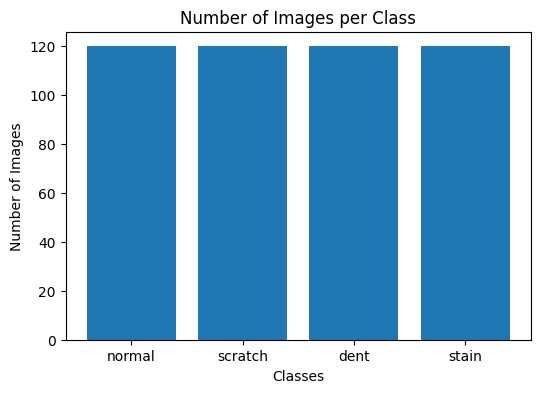

In [13]:
#Plot class distribution
plt.figure(figsize=(6,4))
plt.bar(image_count.keys(), image_count.values())

plt.title("Number of Images per Class")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

plt.show()

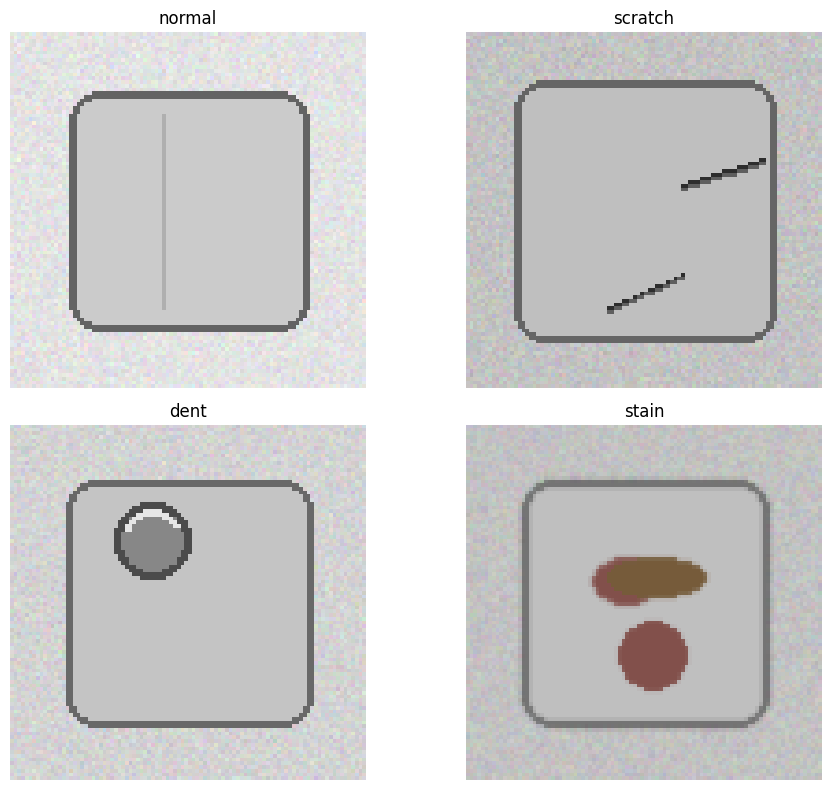

In [14]:
#3. Display Sample Images from Each Class

plt.figure(figsize=(10,8))

for i, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    # Read image using PIL
    img = Image.open(img_path)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
#4. Check Image Dimensions

print("\nSample Image Dimensions:")

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    img_name = os.listdir(class_path)[0]
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    print(f"{cls}: {img.size}")


Sample Image Dimensions:
normal: (96, 96)
scratch: (96, 96)
dent: (96, 96)
stain: (96, 96)


In [16]:
#5. Check Dataset Imbalance
max_images = max(image_count.values())
min_images = min(image_count.values())

print("\nDataset Imbalance Analysis")

if max_images - min_images <= 5:
    print("Dataset is balanced.")
else:
    print("Dataset is imbalanced.")


Dataset Imbalance Analysis
Dataset is balanced.


# Task 3: Image Preprocessing

In [17]:
# Import required libraries
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [18]:
# Image Size
IMG_SIZE = 128

X = []
y = []

In [19]:
# Load, Resize and Label Images
for label, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        # Open image
        img = Image.open(img_path)

        # Convert image to RGB
        img = img.convert("RGB")

        # Resize image
        img = img.resize((IMG_SIZE, IMG_SIZE))

        # Convert image to numpy array
        img_array = np.array(img)

        X.append(img_array)
        y.append(label)

# Convert lists into numpy arrays
X = np.array(X)
y = np.array(y)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)


Dataset Shape: (480, 128, 128, 3)
Labels Shape: (480,)


In [20]:
# Normalize Pixel Values
X = X / 255.0

print("\nPixel values normalized")


Pixel values normalized


In [21]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)



Training Set Shape: (384, 128, 128, 3)
Testing Set Shape: (96, 128, 128, 3)


In [22]:
# Data Augmentation
train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_datagen.fit(X_train)

print("\nData augmentation applied")


Data augmentation applied


# Task 4: CNN Model Creation

In [23]:
# Task 4: CNN Model Creation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [24]:
# Create CNN Model
model = Sequential()

In [25]:
# First Convolution Layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
# Second Convolution Layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

In [27]:
# Third Convolution Layer
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

In [28]:
# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

In [29]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Task 5: Model Training and Evaluation

In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [32]:
# Train CNN Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.2280 - loss: 1.4528 - val_accuracy: 0.2208 - val_loss: 1.3843
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 973ms/step - accuracy: 0.2899 - loss: 1.3829 - val_accuracy: 0.2208 - val_loss: 1.3705
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2704 - loss: 1.3483 - val_accuracy: 0.3506 - val_loss: 1.2887
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.4658 - loss: 1.2207 - val_accuracy: 0.7662 - val_loss: 1.0149
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 928ms/step - accuracy: 0.6189 - loss: 0.9620 - val_accuracy: 0.8312 - val_loss: 0.8266
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7134 - loss: 0.7165 - val_accuracy: 0.7532 - val_loss: 0.7363
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7980 - loss: 0.5647 - val_accuracy: 0.8831 - val_loss: 0.3685
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.7915 - loss: 0.5099 - val_accuracy: 0.9091 - val_

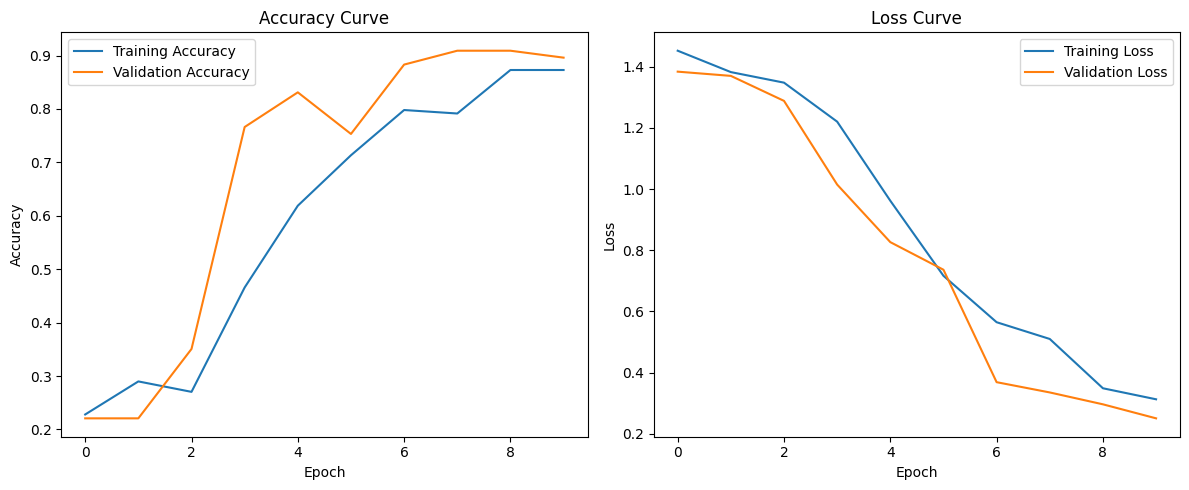

In [42]:
import os
os.makedirs("results", exist_ok=True)

plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

# Loss Plot
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

# Save figure
plt.savefig("results/accuracy_loss_curves.png")

plt.show()

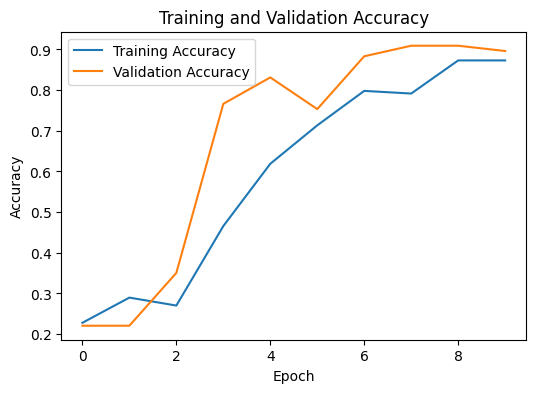

In [33]:
# Plot Training and Validation Accuracy
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

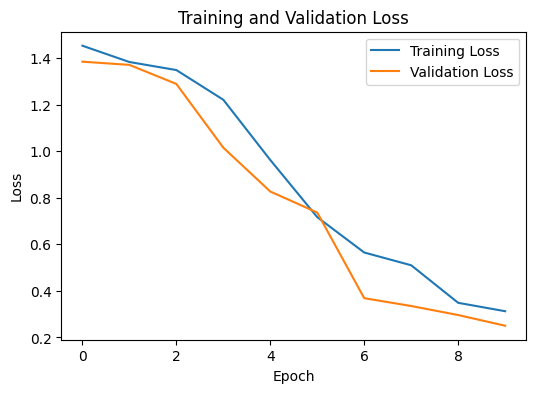

In [34]:
# Plot Training and Validation Loss
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.savefig("results/accuracy_loss_curves.png")
plt.show()

In [35]:
# Evaluate Model on Test Dataset
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step - accuracy: 0.8750 - loss: 0.3330

Test Loss: 0.3330049216747284
Test Accuracy: 0.875


In [36]:
# Predict on Test Dataset
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 275ms/step


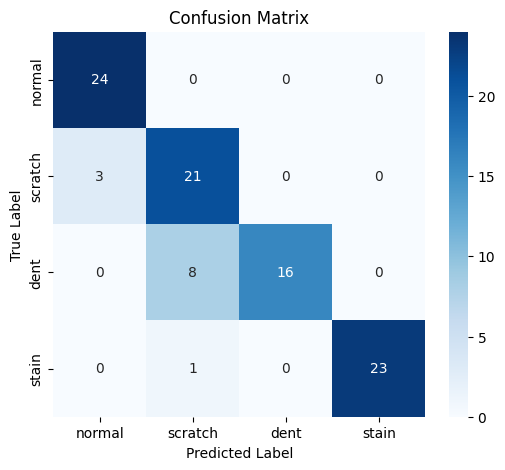

In [37]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [38]:
# Classification Report
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred, target_names=classes))



Classification Report:

              precision    recall  f1-score   support

      normal       0.89      1.00      0.94        24
     scratch       0.70      0.88      0.78        24
        dent       1.00      0.67      0.80        24
       stain       1.00      0.96      0.98        24

    accuracy                           0.88        96
   macro avg       0.90      0.88      0.87        96
weighted avg       0.90      0.88      0.87        96



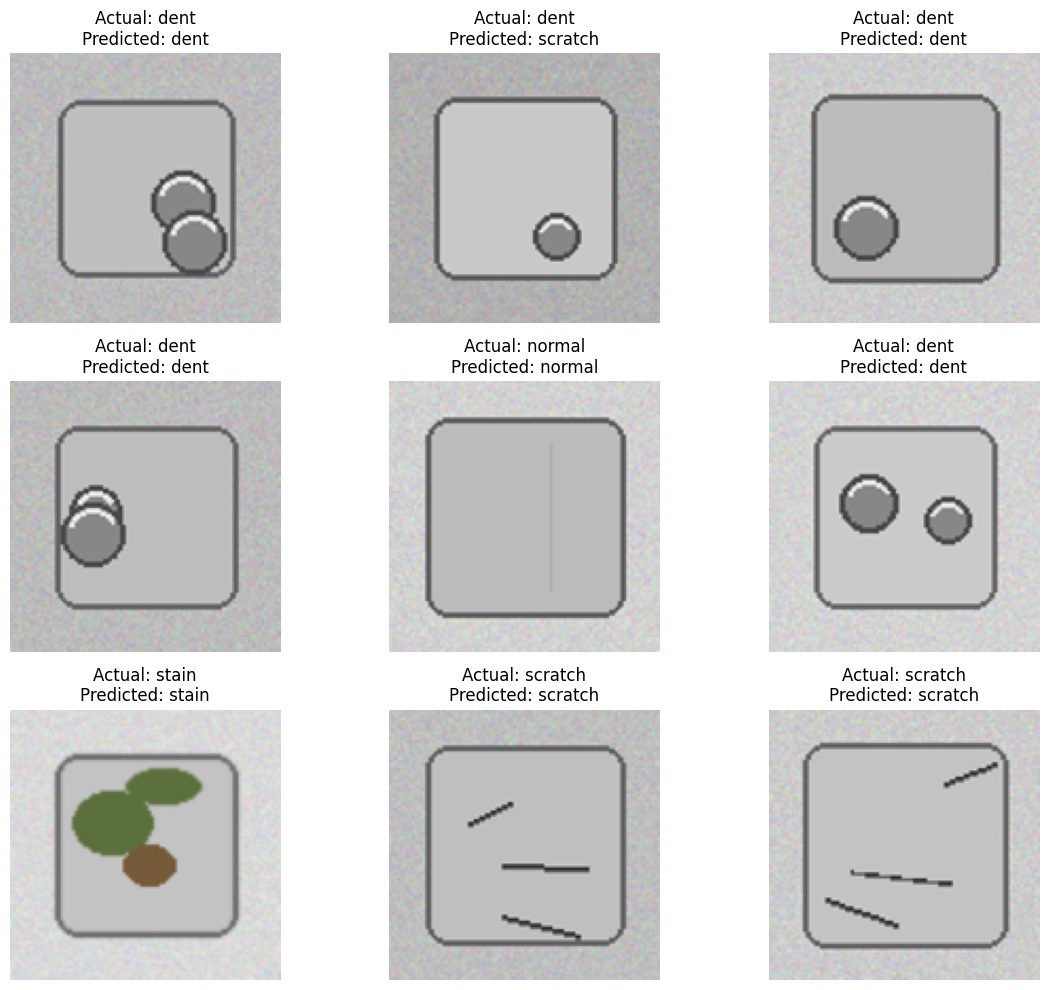

In [39]:
# Display Sample Predictions
plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i])

    actual_label = classes[y_test[i]]
    predicted_label = classes[y_pred[i]]

    plt.title(f"Actual: {actual_label}\nPredicted: {predicted_label}")

    plt.axis("off")

plt.tight_layout()

plt.show()